Repositório já existe
Total de trechos extraídos: 40

Gerando embeddings...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings gerados. Formato: (40, 384)

Calculando o número ideal de clusters (Elbow Method)...


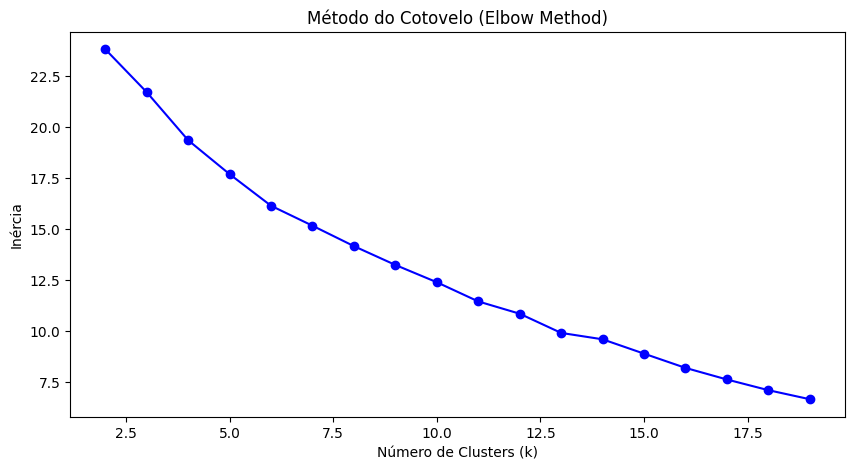

--- Padrões Arquiteturais Identificados (IA + Heurística) ---

Cluster 0 (Total de Arquivos: 5)
Padrão Sugerido: Configuração
Rótulo do Protótipo (Prova): app/config/config.py
  Exemplos Mais Representativos (para confirmar):
    - app/config/config.py
    - main.py
    - app/config/__init__.py
    - app/models/exception.py
    - docker-compose.yml

Cluster 1 (Total de Arquivos: 4)
Padrão Sugerido: Service (Lógica de Negócio)
Rótulo do Protótipo (Prova): test/services/test_video.py
  Exemplos Mais Representativos (para confirmar):
    - test/services/test_video.py
    - test/services/test_task.py
    - test/README.md
    - test/services/test_voice.py

Cluster 2 (Total de Arquivos: 5)
Padrão Sugerido: Interface de Usuário (Frontend)
Rótulo do Protótipo (Prova): webui/i18n/de.json
  Exemplos Mais Representativos (para confirmar):
    - webui/i18n/de.json
    - webui/i18n/zh.json
    - webui/i18n/vi.json
    - webui/i18n/pt.json
    - webui/i18n/en.json

Cluster 3 (Total de Arquivos: 8)
P

In [ ]:
!pip install sentence-transformers gitpython scikit-learn pandas matplotlib

import os
import git
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

url = "https://github.com/harry0703/MoneyPrinterTurbo.git"
dir = "./repo"

if not os.path.exists(dir):
    git.Repo.clone_from(url, dir)
    print(f"Repositório clonado")
else:
    print("Repositório já existe")

# Carregar o modelo e gerar os embeddings

#Seleciona um modelo de IA
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
#verifica se uma GPU está disponível para aceleraar o processamento
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# carrega o modelo na memoria
model = SentenceTransformer(model_name, device=device)

# Varre a pasta do repositorio filtrando arquivos válidos para análise
def extrair_snippets_por_arquivo(path):
    snippets = []
    file_info = []
    valid_exts = (".py", ".json", ".yml", ".md")

    IGNORE_DIRS_SET = {'venv', 'node_modules', '.git', '__pycache__', 'dist'}

    for root, _, files in os.walk(path):
        # Transforma o 'root' em uma lista de nomes de diretório
        path_parts = set(root.split(os.sep))

        # Se qualquer parte do caminho estiver no set de ignorados, pule
        if not IGNORE_DIRS_SET.isdisjoint(path_parts):
            continue

        for file in files:
            if file.endswith(valid_exts):
                filepath = os.path.join(root, file)
                try:
                    if os.path.getsize(filepath) > 500 * 1024: # 500 KB limite
                        continue

                    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                        code = f.read()

                        if len(code.strip()) > 50:
                            full_snippet = f"File: {filepath.replace(path, '')}\n{code}"
                            snippets.append(full_snippet)
                            file_info.append(filepath.replace(path + os.sep, ''))

                except Exception as e:
                    continue

    return snippets, file_info

snippets, filenames = extrair_snippets_por_arquivo(dir)
print(f"Total de trechos extraídos: {len(snippets)}")

if len(snippets) == 0:
    print("Nenhum snippet encontrado. Encerrando.")
    exit()

print("\nGerando embeddings...")
embeddings_tensor = model.encode(snippets, convert_to_numpy=True, show_progress_bar=True)
print(f"Embeddings gerados. Formato: {embeddings_tensor.shape}")

print("\nCalculando o número ideal de clusters (Elbow Method)...")
inertias = []
K_range = range(2, min(20, len(snippets))) # Não pode ter mais clusters que arquivos

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(embeddings_tensor)
    inertias.append(kmeans_test.inertia_)

# Plotar o gráfico
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo (Elbow Method)')
plt.show()

# Analisando o gráfico, o método do cotovelo sugere que o número ideial de clusters é 8
N_CLUSTERS = 8

# utiliza o modelo de agrupamento k-means, que segmenta elementos com características semelhantes na quantidade de clusters escolhidos
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
# realiza a previsão categorizando cada arquivo em um custer com base na proximidade matemaática
cluster_labels = kmeans.fit_predict(embeddings_tensor)

# cria um dataframe com 3 colunas: nome do arquivo, cluster em que foi colocado e o código
df_results = pd.DataFrame({
    'filepath': filenames,
    'cluster': cluster_labels,
    'snippet': snippets
})

# Obter os centros dos clusters
cluster_centers = kmeans.cluster_centers_

print("--- Padrões Arquiteturais Identificados (IA + Heurística) ---")

pattern_keywords = {
    'controller': "Padrão Sugerido: Controller/API (Camada de Apresentação)",
    'api': "Padrão Sugerido: Controller/API (Camada de Apresentação)",
    'router': "Padrão Sugerido: Roteamento (Camada de Apresentação)",
    'service': "Padrão Sugerido: Service (Lógica de Negócio)",
    'manager': "Padrão Sugerido: Manager (Gerenciamento de Estado/Lógica)",
    'repo': "Padrão Sugerido: Repository/DAO (Camada de Persistência)",
    'database': "Padrão Sugerido: Repository/DAO (Camada de Persistência)",
    'model': "Padrão Sugerido: Model/Entidade (Camada de Domínio)",
    'schema': "Padrão Sugerido: Schema/DTO (Transferência de Dados)",
    'test': "Padrão Sugerido: Testes Unitários/Integração",
    'util': "Padrão Sugerido: Utilitários",
    'config': "Padrão Sugerido: Configuração",
    'main': "Padrão Sugerido: Ponto de Entrada (Main)",
    'webui': "Padrão Sugerido: Interface de Usuário (Frontend)",
    'i18n': "Padrão Sugerido: Internacionalização (i18n)",
    'docker': "Padrão Sugerido: Infraestrutura (Docker)",
    'github': "Padrão Sugerido: CI/CD ou Metadados do Repositório",
    '.md': "Padrão Sugerido: Documentação"
}

for i in sorted(df_results['cluster'].unique()):

    # Filtra o dataframe e os embeddings para este cluster
    cluster_df = df_results[df_results['cluster'] == i]
    cluster_embeddings = embeddings_tensor[cluster_df.index]

    # Pega o centro deste cluster
    center_vec = cluster_centers[i]

    # Calcula a distância de cada arquivo no cluster até o centro
    distances = util.cos_sim(center_vec.reshape(1, -1), cluster_embeddings)[0]

    # Encontra os 5 mais próximos
    top_k_indices_in_cluster = torch.topk(distances, k=min(5, len(cluster_df)))[1]
    original_indices = cluster_df.index[top_k_indices_in_cluster.cpu().numpy()]
    representative_files = df_results.loc[original_indices, 'filepath'].tolist()
    prototype_file = representative_files[0]


    # --- LÓGICA DA HEURÍSTICA ---
    # Aplica a heurística ao nome do protótipo
    prototype_lower = prototype_file.lower()
    suggestion = "Padrão Sugerido: Módulo Genérico/Outros" # Padrão default

    for keyword, text in pattern_keywords.items():
        if keyword in prototype_lower:
            suggestion = text
            break # Usa a primeira palavra-chave que encontrar

    # --- IMPRESSÃO ---
    print(f"\n========================================================")
    print(f"Cluster {i} (Total de Arquivos: {len(cluster_df)})")
    print(f"========================================================")

    # 1. A Heurística
    print(f"{suggestion}")

    # 2. A "Prova" (O arquivo que gerou a heurística)
    print(f"Rótulo do Protótipo (Prova): {prototype_file}")

    # 3. Outros exemplos
    print("  Exemplos Mais Representativos (para confirmar):")
    for filepath in representative_files:
        print(f"    - {filepath}")
